# Глава 7. Модель Prophet и перекрёстная проверка (`backtest`)

# 1. Теория

## 1.1 Идея Prophet

**Prophet** — модель, которая смотрит на ряд не как на цепочку «следующее значение из предыдущих», а как на **кривую, которую надо провести через точки**. Время — это просто ось X, а прогноз — та же кривая, продолженная вправо. Ряд раскладывается на сумму понятных слагаемых, и каждое подгоняется регрессией:

$$\LARGE y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

где:
- $\large y(t)$ — значение ряда в момент $\large t$ (заказы юнита за день).
- $\large g(t)$ — **тренд**: кусочно-линейная функция времени. Прямая, которая в некоторых точках может «переломиться» и сменить наклон.
- $\large s(t)$ — **сезонность**: сумма периодических волн — недельной, годовой, суточной.
- $\large h(t)$ — **праздники и события**: разовые поправки на конкретные даты из заданного списка.
- $\large \varepsilon_t$ — шум, который модель не объясняет.

### Тренд: прямая с изломами
$$\LARGE g(t) = \Big(k + \sum_{j:\, s_j \le t} \delta_j\Big)\, t + \Big(m + \sum_{j:\, s_j \le t} \gamma_j\Big)$$

где:
- $\large k$ — начальный наклон тренда, $\large m$ — начальное смещение.
- $\large s_j$ — **точки излома** (changepoints): даты, в которых тренд может сменить наклон. По умолчанию — 25 штук, равномерно расставленных по первым 80% истории.
- $\large \delta_j$ — **изменение наклона** в точке $\large s_j$. После каждого пройденного излома наклон становится $\large k + \delta_1 + \ldots + \delta_j$.
- $\large \gamma_j$ — поправка смещения, которая подбирается автоматически, чтобы прямая в точке излома не «рвалась».

Ключевой момент: Prophet ставит изломы **всюду**, а потом штрафует их. На $\large \delta_j$ наложено априорное распределение Лапласа с масштабом `changepoint_prior_scale`: большинство $\large \delta_j$ сжимаются в 0, «выживают» только изломы, которые реально нужны данным. Маленький масштаб — тренд почти прямой, большой — тренд гибкий и гоняется за каждым поворотом.

### Сезонность: ряд Фурье
$$\LARGE s(t) = \sum_{n=1}^{N} \left( a_n \cos\frac{2\pi n t}{P} + b_n \sin\frac{2\pi n t}{P} \right)$$

где:
- $\large P$ — период сезонности в днях: 7 для недельной, 365.25 для годовой.
- $\large N$ — порядок ряда Фурье (`fourier_order`): сколько гармоник складываем. Больше $\large N$ — форма волны сложнее и острее, но выше риск переобучения. По умолчанию: недельная $\large N=3$, годовая $\large N=10$.
- $\large a_n, b_n$ — коэффициенты, которые подбираются регрессией.

Недельная волна с $\large N=3$ — это 6 коэффициентов на 7 дней недели, то есть почти «отдельная поправка на каждый день», как у сезонного индекса `HoltWintersModel`. Но годовая волна — 20 коэффициентов на 365 дней: гладкая кривая вместо 365 отдельных поправок.

### Как модель обучается и прогнозирует
- Все параметры ($\large k, m, \delta, a_n, b_n$, эффекты праздников) подбираются **одной задачей оптимизации** — MAP-оценка в Stan (через `cmdstanpy`). Отсюда служебные логи `cmdstanpy - INFO - Chain [1] ...` при каждом `fit()`.
- Прогноз на дату $\large t$ — просто значение $\large g(t) + s(t) + h(t)$ в этой точке. **Прогноз не рекурсивный**: модель не подставляет свои прогнозы вместо факта, и прогноз на 10-й день не зависит от прогноза на 9-й. Тренд за пределами истории — продолжение **последнего** отрезка прямой.

### Отличие от
- `HoltWintersModel` тоже раскладывает ряд на уровень / тренд / сезонность, но обновляет их **рекурсивно**, шаг за шагом, с экспоненциальным забыванием прошлого (α/β/γ). Prophet подгоняет всю историю **сразу одной кривой**: свежие точки не весят больше старых, зато смена тренда описывается явно — изломом в конкретную дату.
- `SARIMAXModel` моделирует зависимость значения от прошлых значений и ошибок (AR/MA) и требует стационарности. Prophet никакой авторегрессии не содержит: в нём нет лагов, только функции времени. Поэтому стационарность ему не нужна, пропуски в истории не мешают, а неравномерные даты допустимы.

## 1.2 Параметры и реализация

Исходник `etna/models/prophet.py`, класс `ProphetModel` (сигнатура без сокращений — все параметры пробрасываются в `prophet.Prophet` один в один):

```python
class ProphetModel(
    PerSegmentModelMixin, PredictionIntervalContextIgnorantModelMixin, PredictionIntervalContextIgnorantAbstractModel
):
    def __init__(
        self,
        growth: str = "linear",
        changepoints: Optional[List[datetime]] = None,
        n_changepoints: int = 25,
        changepoint_range: float = 0.8,
        yearly_seasonality: Union[str, bool] = "auto",
        weekly_seasonality: Union[str, bool] = "auto",
        daily_seasonality: Union[str, bool] = "auto",
        holidays: Optional[pd.DataFrame] = None,
        seasonality_mode: str = "additive",
        seasonality_prior_scale: float = 10.0,
        holidays_prior_scale: float = 10.0,
        changepoint_prior_scale: float = 0.05,
        mcmc_samples: int = 0,
        interval_width: float = 0.8,
        uncertainty_samples: Union[int, bool] = 1000,
        stan_backend: Optional[str] = None,
        additional_seasonality_params: Iterable[Dict[str, Union[str, float, int]]] = (),
        timestamp_column: Optional[str] = None,
    ):
```

**Параметры `ProphetModel`:**

*Тренд $g(t)$:*
- `growth` *(по умолчанию `"linear"`)* — тип тренда: `"linear"` — кусочно-линейный; `"flat"` — тренда нет, константа; `"logistic"` — рост с насыщением к потолку `cap` (нужна колонка `cap` в данных как регрессор).
- `n_changepoints` *(25)* / `changepoint_range` *(0.8)* — сколько кандидатов в изломы и на какой доле истории их расставлять (первые 80%).
- `changepoints` — явный список дат изломов вместо автоматической расстановки.
- `changepoint_prior_scale` *(0.05)* — **гибкость тренда**: масштаб априорного распределения на $\delta_j$. Главный параметр для настройки.

*Сезонность $s(t)$:*
- `weekly_seasonality` / `yearly_seasonality` / `daily_seasonality` *(`"auto"`)* — `True`/`False`, число (= `fourier_order`) или `"auto"`. Правила `"auto"` из исходника `prophet`: недельная включается при истории ≥ 2 недель и шаге < 7 дней; годовая — при истории **≥ 730 дней (2 года)**; суточная — только при шаге < 1 дня.
- `seasonality_mode` *(`"additive"`)* — `"additive"`: $y = g + s$, или `"multiplicative"`: $y = g \cdot (1 + s)$ — размах волны пропорционален тренду.
- `seasonality_prior_scale` *(10.0)* — сила сезонности: меньше → волны сглаживаются к нулю.
- `additional_seasonality_params` — свои сезонности: список словарей для `Prophet.add_seasonality(name=..., period=..., fourier_order=...)`, например месячная `period=30.5`.

*Праздники $h(t)$:*
- `holidays` — датафрейм с колонками `holiday`, `ds` и опционально `lower_window` / `upper_window` (сколько дней до/после тоже считать праздником).
- `holidays_prior_scale` *(10.0)* — сила эффекта праздников.

*Остальное:*
- `mcmc_samples` *(0)* — 0: точечная MAP-оценка (быстро); > 0: полный байесовский вывод (медленно).
- `interval_width` / `uncertainty_samples` — ширина и число симуляций для интервалов прогноза.
- `timestamp_column` — брать время не из индекса, а из колонки-регрессора.

**В отличие от `HoltWintersModel`:**
- внутри — `prophet.Prophet`, а не `statsmodels`; обучение — оптимизация в Stan;
- **экзогенные регрессоры поддерживаются**: колонки, объявленные в `TSDataset` как `known_future`, ETNA сама передаёт в `Prophet.add_regressor()`. Колонки, неизвестные в будущем, игнорируются с предупреждением;
- **поддерживаются интервалы прогноза**: `model.forecast(future_ts, prediction_interval=True, quantiles=[0.025, 0.975])`;
- нет коэффициентов сглаживания: вместо α/β/γ — априорные масштабы `*_prior_scale`, которые задают не «скорость забывания», а «сколько свободы дать компоненте»;
- то же самое общее: `PerSegmentModelMixin` — отдельная модель на каждый сегмент; API `fit` → `make_future(HORIZON)` → `forecast`; `get_model()` → `{segment: prophet.Prophet}`; `forecast(..., return_components=True)` даёт разложение `target_component_trend`, `target_component_weekly`, `target_component_yearly`, ...

## 1.3 Особенности

- **Изломы только в первых 80% истории** (`changepoint_range=0.8`). Если тренд переломился в последние 20% train — а это самая важная часть для прогноза, — Prophet излом не увидит и продолжит старый наклон. Лечится `changepoint_range=0.9..0.95` или явным списком `changepoints`.
- **Прогноз тренда — продолжение последнего отрезка.** На длинном горизонте прямая уходит в небо или в ноль, как незатухающий тренд у `HoltWintersModel`. Для рядов без направления есть `growth="flat"`.
- **Нет рекурсии — нет «золотого правила».** В отличие от `MovingAverageModel` / `SeasonalMovingAverageModel`, прогноз Prophet на день `t+10` не опирается на прогноз дня `t+9`. Поэтому любую дату можно спрогнозировать напрямую, не считая промежуточные дни, а на длинном горизонте прогноз не вырождается в константу, как у рекурсивных моделей.
- **Годовая сезонность включается автоматически только при истории ≥ 2 лет.** На наших стандартных 5 месяцах (с 2026-04-01) её не будет — модель видит только тренд + недельную волну. Чтобы Prophet показал свою сильную сторону, нужна длинная история.
- **Разложение на компоненты работает только для аддитивного режима.** С `seasonality_mode="multiplicative"` вызов `forecast(..., return_components=True)` в ETNA падает с `ValueError: Forecast decomposition is only supported for additive components!` — компоненты тогда смотрим через `model.get_model()[segment].predict(...)` из самого `prophet`.
- **Шумные логи.** Каждый `fit()` пишет в лог `cmdstanpy`; на 10 юнитах × 5 фолдов это сотни строк. Отключаются через `logging.getLogger("cmdstanpy").disabled = True` (уже в ячейке импортов).
- **Праздники** — главная фишка Prophet, но в этой главе не используем: в тестовом окне 2026-08-18 … 2026-08-31 праздников нет. Вернёмся к ним, когда дойдём до регрессоров.

## 1.4 Перекрёстная проверка: `Pipeline.backtest`

До сих пор мы оценивали модели на **одном** тестовом окне — последних 14 днях. Это одна точка: если именно эти две недели оказались необычными, вывод «модель A лучше B» может оказаться случайным. **Перекрёстная проверка на временных рядах** (backtest) повторяет «обучи → спрогнозируй → посчитай метрику» несколько раз, сдвигая тестовое окно назад по истории, и смотрит на ошибку по всем окнам.

```
expand (расширяющееся окно)              constant (скользящее окно)
fold 0: [train====]  [test]              fold 0: [train====]  [test]
fold 1: [train========]  [test]          fold 1:     [train====]  [test]
fold 2: [train============]  [test]      fold 2:         [train====]  [test]
```

- **`mode="expand"`** *(по умолчанию)* — начало train всегда одно и то же, каждый следующий фолд добавляет историю. Так модель живёт в проде: переобучается на всём, что накопилось.
- **`mode="constant"`** — train одной длины, окно скользит. Полезно, когда старая история вредит (ряд поменял поведение) или чтобы сравнивать фолды «при равных условиях».
- Тестовые окна идут **подряд и не пересекаются**: последний фолд — это ровно наш обычный holdout (последние `horizon` точек), предыдущие — `horizon` точек перед ним и т. д.

`backtest` запускается не у модели, а у **конвейера** `Pipeline(model, transforms, horizon)`: преобразования (их добавим дальше, вместе с конструированием признаков) должны обучаться заново на каждом фолде, иначе информация из теста просочится в train.

Исходник `etna/pipeline/base.py`, метод `BasePipeline.backtest` (ETNA 3.0.0):

```python
def backtest(
    self,
    ts: TSDataset,
    metrics: List[BaseMetric],
    n_folds: Union[int, List[FoldMask]] = 5,
    mode: Optional[str] = None,
    aggregate_metrics: bool = False,
    n_jobs: int = 1,
    refit: Union[bool, int] = True,
    stride: Optional[int] = None,
    joblib_params: Optional[Dict[str, Any]] = None,
    forecast_params: Optional[Dict[str, Any]] = None,
) -> Dict[str, Union[pd.DataFrame, List[TSDataset], List[Self]]]:
```

**Параметры:**
- `ts` — **весь** ряд (train + test): фолды нарезаются внутри;
- `metrics` — список метрик, например `[SMAPE(), MAE()]`;
- `n_folds` *(5)* — число фолдов, либо явный список `FoldMask`;
- `mode` — `"expand"` / `"constant"`;
- `aggregate_metrics` *(False)* — `True`: одна строка на сегмент со средним по фолдам; `False`: строка на каждую пару (сегмент, фолд);
- `refit` *(True)* — переобучать модель на каждом фолде; `False` — обучить один раз на первом; число `k` — переобучать каждые `k` фолдов;
- `stride` — шаг между фолдами, по умолчанию = `horizon` (окна встык);
- `n_jobs` — параллельно по фолдам; `joblib_params=dict(verbose=0)` убирает прогресс-лог joblib.

**Важное расхождение с пособием.** В пособии (ETNA 2.x) `backtest` возвращает кортеж из трёх датафреймов: `metrics_df, forecast_df, fold_info_df = pipeline.backtest(...)`. В ETNA 3.0.0 он возвращает **словарь**:
- `result["metrics"]` — метрики: сегмент × фолд (или сегмент, если `aggregate_metrics=True`);
- `result["forecasts"]` — **список** `TSDataset`, по одному прогнозу на фолд (а не один широкий датафрейм);
- `result["fold_info"]` — даты train/test каждого фолда;
- `result["pipelines"]` — обученные конвейеры каждого фолда.

Соответственно и `plot_backtest(result["forecasts"], ts, history_len=...)` принимает список прогнозов.

# 2. Данные

Те же файлы, что и в предыдущих тетрадях (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.

Период и сплит — как в прошлых тетрадях: с 2026-04-01, test — последние 14 дней (2026-08-18 … 2026-08-31). Тогда результаты сравнимы с `NaiveModel` / `MovingAverageModel` / `SeasonalMovingAverageModel` / `SARIMAXModel` / `HoltWintersModel` напрямую, в том числе в MLflow.

Новое в этой главе — **длинная история**: у обоих юнитов `10+` факты есть с 2022 года, этого хватает, чтобы Prophet включил годовую сезонность (Задание 6). Тестовое окно при этом то же самое, меняется только длина train.

В этой главе не сравниваем с продовым прогнозом (`forecasts-by-date.csv`) — это отдельная тема, которой займёшься сам.

In [2]:
import logging
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etna.datasets import TSDataset
from etna.models import ProphetModel, HoltWintersModel
from etna.pipeline import Pipeline
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast, plot_backtest

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

# Prophet пишет в лог cmdstanpy на каждом fit() — на 10 юнитах × 5 фолдах это сотни строк
logging.getLogger("cmdstanpy").disabled = True
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = "../../local/data"
HORIZON = 14

# 3. Практика

От простого к сложному: на синтетике смотрим, чем Prophet отличается от `HoltWintersModel` (излом тренда), разбираем прогноз на компоненты и знакомимся с `backtest`. Потом — 2 реальных юнита на стандартном и на длинном периоде, и в бонусе — все 10 юнитов с логированием в MLflow.

## Задание 1. Синтетика: излом тренда

Смотрим, чем Prophet отличается от `HoltWintersModel`, на ряде, где тренд в какой-то момент меняет наклон. Синтетику генерирует функция `make_break_series`, модели сравнивает `compare_models` — так каждый эксперимент со сдвигом излома или параметрами укладывается в одну-две строки.

### Шаг 1.1. Синтетический ряд с изломом

Собери синтетический ряд на 18 недель (126 дней): **кусочно-линейный тренд** — растёт на +2 в день до 70-го дня, потом **падает** на −1 в день, — плюс недельный паттерн и немного шума, как в синтетике для `HoltWintersModel`. Оберни в `TSDataset` с одним сегментом `"synthetic"`.

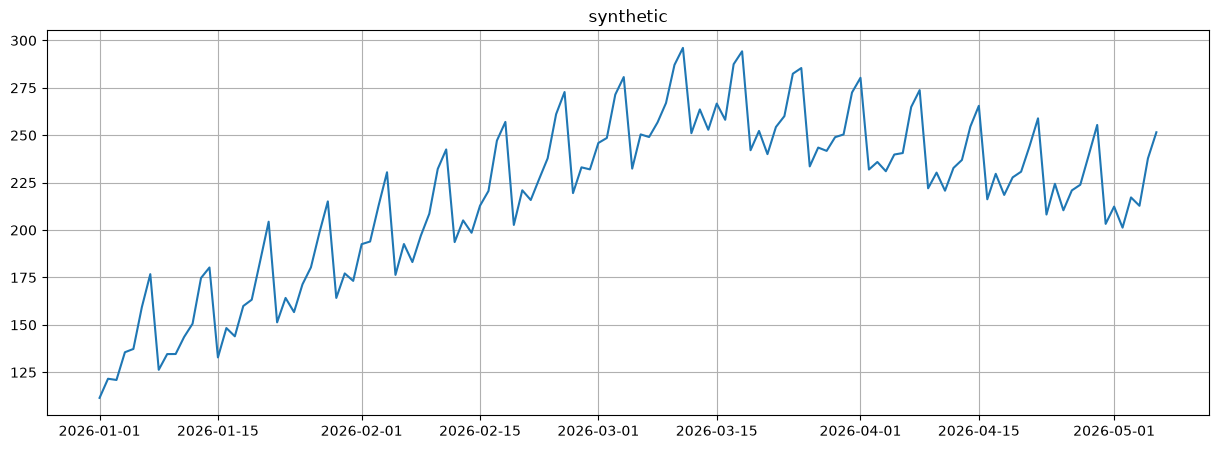

In [3]:
# Шаг 1.1. Генератор синтетики: кусочно-линейный тренд с одним изломом + недельная сезонность + шум
DAY_OF_WEEK_PATTERN = np.array([10, 20, 15, 25, 30, 50, 60], dtype=float)


def make_break_series(
    break_day: int = 70,        # день излома (отсчёт от 0)
    periods: int = 126,         # длина ряда: 18 недель
    slope_before: float = 2,    # наклон до излома, в день
    slope_after: float = -1,    # наклон после излома, в день
    start_level: float = 100,
    noise_sd: float = 3,
    seed: int = 42,
) -> TSDataset:
    rng = np.random.RandomState(seed)  # тот же шум, что np.random.seed(seed) + np.random.normal
    t = np.arange(periods)

    # После излома отсчёт идёт от значения тренда в точке излома, чтобы прямая не «рвалась»
    level_at_break = start_level + slope_before * break_day
    trend = np.where(
        t < break_day,
        start_level + slope_before * t,
        level_at_break + slope_after * (t - break_day),
    )
    seasonal = np.tile(DAY_OF_WEEK_PATTERN, periods // 7 + 1)[:periods]
    noise = rng.normal(0, noise_sd, periods)

    df = pd.DataFrame({
        "timestamp": pd.date_range("2026-01-01", periods=periods, freq="D"),
        "segment": "synthetic",
        "target": trend + seasonal + noise,
    })
    return TSDataset(df=df, freq="D")


ts = make_break_series()  # излом на 70-м дне
ts.plot(figsize=(15, 5));

### Шаг 1.2. ETS против Prophet

Обучи `ProphetModel()` с параметрами по умолчанию и `HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)` на train (test — последние 14 дней). Нарисуй оба прогноза на одном графике и посчитай SMAPE.

In [14]:
def make_models(**extra) -> dict:
    """Базовая пара ETS + Prophet; через extra можно добавить свои: make_models(prophet_cr95=ProphetModel(changepoint_range=0.95))."""
    return {
        "ets": HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7),
        "prophet": ProphetModel(),
        **extra,
    }


def compare_models(ts: TSDataset, models: dict, n_train_samples: int | None = None, plot: bool = True) -> dict:
    """Каждой модели: fit на train → прогноз на HORIZON → SMAPE на test. Модели передавай свежие (make_models())."""
    train_ts, test_ts = ts.train_test_split(test_size=HORIZON)

    forecasts = {}
    for name, model in models.items():
        model.fit(train_ts)
        forecasts[name] = model.forecast(train_ts.make_future(future_steps=HORIZON))

    errors = pd.Series({
        name: SMAPE()(y_true=test_ts, y_pred=forecast)["synthetic"]
        for name, forecast in forecasts.items()
    }, name="smape").round(2)

    if plot:
        plot_forecast(
            forecast_ts=forecasts,
            test_ts=test_ts,
            train_ts=train_ts,
            n_train_samples=n_train_samples,
            figsize=(15, 5),
        )
    return {"models": models, "forecasts": forecasts, "errors": errors, "train_ts": train_ts, "test_ts": test_ts}

ets        2.46
prophet    1.35
Name: smape, dtype: float64


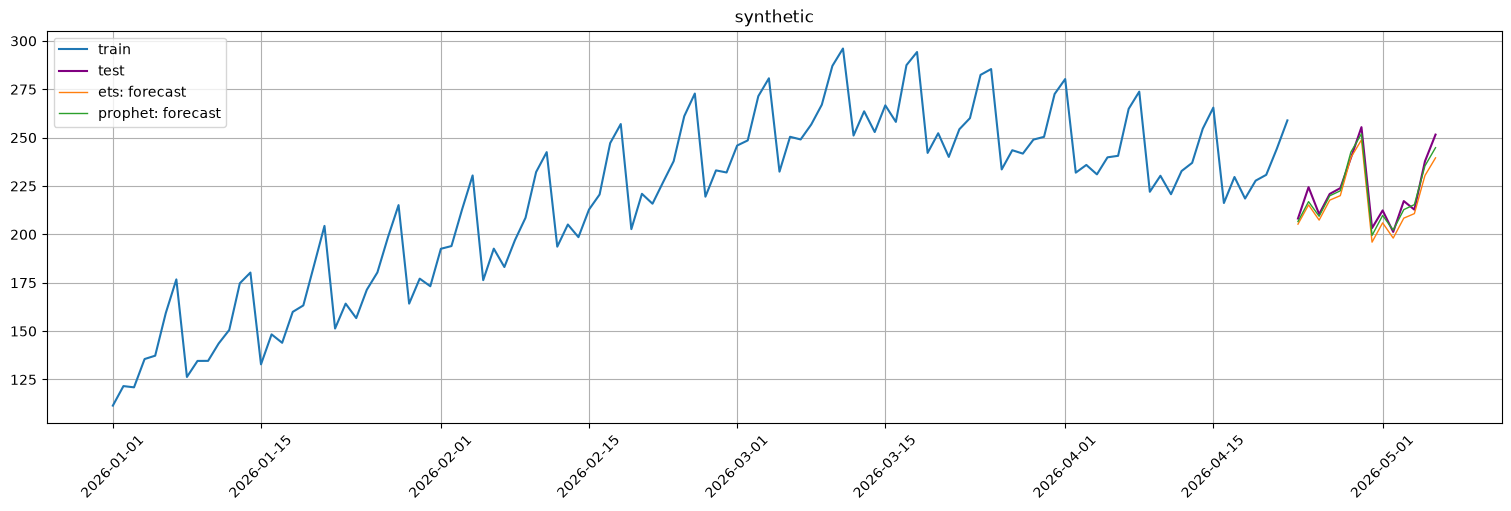

In [18]:
res = compare_models(ts, make_models())
model_ets, model_prophet = res["models"]["ets"], res["models"]["prophet"]
train_ts, test_ts = res["train_ts"], res["test_ts"]

print(res["errors"])

### Шаг 1.3. Кто точнее и почему

- Кто точнее спрогнозировал тест?
- Вспомни раздел 1.1: как каждая модель узнаёт, что наклон сменился, и насколько точно оценивает новый наклон?

#### Выводы

- ETS узнаёт про излом по ошибкам: несколько дней промахивается, сдвигает наклон на долю β, и примерно через неделю перестраивается. Его наклон в любой момент — это мнение по последним дням. Он быстро реагирует на изменения, но шумит.
- Prophet находит излом задним числом, глядя на всю историю, и оценивает наклон по всему участку после излома. Он подгоняет одну прямую по всем 42 точкам после излома, и шум отдельных дней усредняется. Отсюда 1.35 против 2.46.

### Шаг 1.4. Излом ближе к концу train

Сдвинь излом на 95-й день (train — дни 0…111). Сравни `HoltWintersModel`, `ProphetModel()` и `ProphetModel(changepoint_range=0.95)`, потом прогони несколько положений излома одной таблицей.

- Почему Prophet по умолчанию теперь проигрывает ETS? Вспомни раздел 1.3: где Prophet расставляет кандидатов в изломы?
- А если сдвинуть излом за конец train, в тест: может ли его поймать хоть одна модель?

ets             2.20
prophet         4.33
prophet_cr95    0.77
Name: smape, dtype: float64


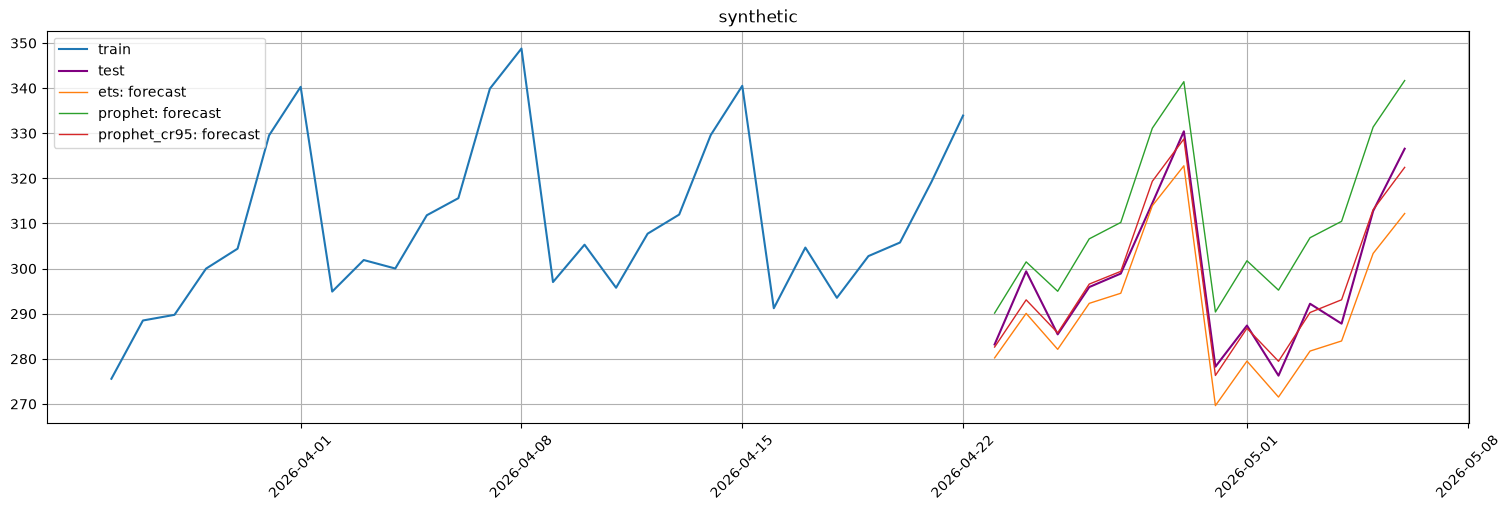

In [20]:
ts_95 = make_break_series(break_day=95)
res_95 = compare_models(ts_95, make_models(prophet_cr95=ProphetModel(changepoint_range=0.95)), n_train_samples=4 * 7)
print(res_95["errors"])

In [21]:
# Прогон по нескольким положениям излома — одна строка на вариант. 115 — излом уже в тесте (train заканчивается на 111-м дне)
sweep = pd.DataFrame({
    break_day: compare_models(
        make_break_series(break_day=break_day),
        make_models(prophet_cr95=ProphetModel(changepoint_range=0.95)),
        plot=False,
    )["errors"]
    for break_day in [40, 70, 85, 95, 105, 115]
}).T.rename_axis("break_day")
sweep

,ets,prophet,prophet_cr95
break_day,,,
40,3.94,2.28,2.28
70,2.46,1.35,1.29
85,2.01,1.13,1.13
95,2.20,4.33,0.77
105,6.32,8.23,3.07
115,3.15,3.06,3.07


#### Выводы

Train — дни 0…111. При `changepoint_range=0.8` Prophet расставляет кандидатов в изломы только до ~89-го дня (112 × 0.8), при `0.95` — до ~106-го.

- **Излом на 40 / 70 / 85-м дне — Prophet лучше ETS примерно в 1.7–1.8 раза.** Излом попадает в зону поиска, Prophet находит его и оценивает новый наклон по всем точкам после излома. ETS тоже перестраивается, но его наклон — мнение по последним шумным дням. `changepoint_range=0.95` здесь ничего не меняет: излом и так в зоне поиска, лишние кандидаты в конце не нужны.
- **Излом на 95-м дне — Prophet по умолчанию проигрывает ETS почти в 2 раза (4.33 против 2.20).** Излом за пределами зоны поиска. Последний кандидат стоит около 89-го дня, и после него Prophet проводит одну прямую через 6 дней роста и 17 дней падения. Получается усреднённый наклон, и модель уходит в тест со слишком высоким трендом. ETS «слепой зоны» не имеет: за 17 дней после излома он успевает перестроиться по ошибкам. С `changepoint_range=0.95` излом попадает в зону поиска, и Prophet снова лучший — 0.77, лучший результат во всей таблице.
- **Излом на 105-м дне — плохо всем (3–8).** После излома в train всего 7 точек. ETS не успевает перестроиться (ему нужна примерно неделя), Prophet по умолчанию излома не видит, а у Prophet с `0.95` слишком мало точек, чтобы уверенно отличить новый тренд от шума и недельной «пилы». Он лучший (3.07), но далёк от хорошего.
- **Излом на 115-м дне — уже в тесте, все три модели дают одно и то же (~3.1).** В train чистый рост +2, все продолжают его в тест. Излом в будущем не может поймать никакая модель: ни ETS, ни Prophet не прогнозируют смену тренда, они только находят её в истории. Ошибка меньше, чем при изломе на 105-м дне, потому что прогноз расходится с фактом только с 4-го дня теста и постепенно.

**Почему не ставить `changepoint_range=0.95` всегда?** Кандидаты в самом конце train подгоняются по считаным точкам, и модель начинает принимать шум последних дней за излом, а потом продолжает этот случайный наклон на весь горизонт. Значение 0.8 по умолчанию защищает от этого ценой слепоты к свежим изломам. На чистой синтетике 0.95 выигрывает, на шумных реальных данных — не факт. Это проверим в Задании 5.

**Оговорка.** Это один ряд с одним шумом (`seed=42`). Устойчив вывод про 95-й день: там Prophet по умолчанию слеп при любом шуме. Разница в 1.5–2 раза на 40–85-м днях может зависеть от конкретного шума. Чтобы это проверить, нужен прогон по нескольким `seed` или `backtest` (Задание 3).

### Шаг 1.5. Гибкость тренда: `changepoint_prior_scale`

Вернись к излому на 70-м дне и повтори Prophet с `changepoint_prior_scale` = `0.001`, `0.05` (по умолчанию), `0.5`.

- Как меняются прогноз и SMAPE?
- Что происходит при очень маленьком значении?

Optimization terminated abnormally. Falling back to Newton.


cps_0.001    24.59
cps_0.05      1.35
cps_0.5       1.38
Name: smape, dtype: float64


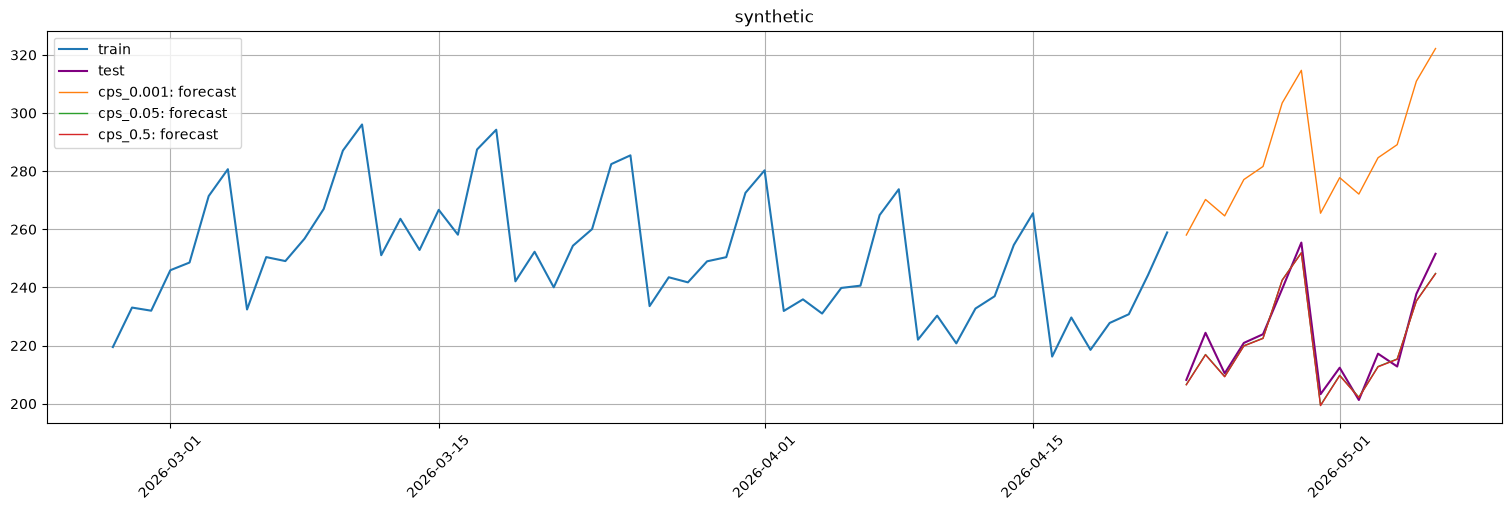

In [23]:
res_cps = compare_models(ts, {f"cps_{c}": ProphetModel(changepoint_prior_scale=c) for c in [0.001, 0.05, 0.5]}, n_train_samples=8 * 7)
print(res_cps["errors"])

#### Выводы

`changepoint_prior_scale` — это штраф на изменения наклона δ в кандидатах-изломах (раздел 1.1). Он задаёт не где искать изломы (это `changepoint_range` из шага 1.4), а насколько охотно модель их признаёт.

- **`0.001` — тренд «заморожен», SMAPE 24.6.** Штраф настолько сильный, что все 25 δ прижаты к нулю, и тренд — одна прямая на весь train. Её наклон +1.07 — компромисс между ростом +2 и падением −1. Модель не видит излома и продолжает рост в тест, хотя ряд давно падает. Отсюда оранжевая линия, уходящая вверх. Сообщение `Falling back to Newton` — побочный эффект: данные требуют излома, штраф его запрещает, и основной оптимизатор не сходится.
- **`0.05` (по умолчанию) — излом найден, SMAPE 1.35.** Выжили 7 из 25 кандидатов (почти все рядом с 70-м днём), наклон в конце train −1.02, почти идеально совпадает с настоящим −1.
- **`0.5` — тренд гибкий, SMAPE 1.38.** Выжили 13 кандидатов, то есть модель «ломает» тренд в куче мест, где излома не было. Но наклон в конце train тот же −1.02, поэтому прогноз почти не отличается от `0.05`.

**Почему лишняя гибкость здесь не навредила?** В синтетике после излома 42 дня чистой прямой с умеренным шумом. Лишние изломы в середине истории на прогноз не влияют: для прогноза важен только последний отрезок, а его наклон однозначен. На реальных шумных данных всё иначе: гибкий тренд начнёт ловить случайные колебания последних недель и экстраполировать их на горизонт. Это проверим в Задании 5.

**Итог:** слишком маленький `changepoint_prior_scale` опаснее слишком большого — модель с замороженным трендом систематически уходит не туда. Значение по умолчанию 0.05 на чистом изломе работает отлично.

## Задание 2. Из чего собран прогноз

Разбираем прогноз Prophet на слагаемые из раздела 1.1 и проверяем, что за ним нет ничего, кроме тренда и недельной волны. Работаем с `model_prophet`, `train_ts` и `test_ts` из Задания 1 (излом на 70-м дне).

### Шаг 2.1. Компоненты прогноза

Для `model_prophet` из Задания 1 получи прогноз на `HORIZON` дней с `return_components=True` и достань компоненты через `get_target_components()`.

- Какие компоненты есть?
- Почему нет `yearly`? (раздел 1.3)

In [27]:
# Прогноз с разложением на компоненты: помимо target вернуть слагаемые, из которых он собран
forecast_comp_ts = model_prophet.forecast(
    train_ts.make_future(future_steps=HORIZON),
    return_components=True,
)

# Компоненты лежат отдельно от target; колонки — (segment, компонента), берём наш сегмент
components = forecast_comp_ts.get_target_components()["synthetic"]
components

feature,target_component_trend,target_component_weekly
timestamp,,
2026-04-23,227.328421,-20.712749
2026-04-24,226.307680,-9.385295
2026-04-25,225.286938,-15.924627
2026-04-26,224.266197,-4.328835
2026-04-27,223.245455,-0.720028
2026-04-28,222.224714,20.311107
2026-04-29,221.203973,30.760427
2026-04-30,220.183231,-20.712749
2026-05-01,219.162490,-9.385295


In [28]:
# Какие сезонности Prophet включил сам (режим "auto") и сколько дней истории он видел
prophet_model = model_prophet.get_model()["synthetic"]  # объект prophet.Prophet
history_days = (prophet_model.history["ds"].max() - prophet_model.history["ds"].min()).days

print("сезонности:", list(prophet_model.seasonalities))
print("дней истории в train:", history_days)

сезонности: ['weekly']
дней истории в train: 111


#### Выводы

- Какие компоненты есть: тренд $g(t)$ и недельная волна $s(t)$ из формулы раздела 1.1. Праздников $h(t)$ нет, потому что мы их не задавали. Регрессоров тоже нет, их в синтетике нет.
- Почему нет yearly: при yearly_seasonality="auto" Prophet включает годовую сезонность, только если история не короче 730 дней (раздел 1.3). У нас 111 дней. Даже если бы мы включили годовую сезонность принудительно, оценить годовую волну по трети года невозможно. Суточной сезонности (daily) тоже нет: данные дневные, внутри дня колебаний нет.

### Шаг 2.2. Компоненты в сумме дают прогноз

Проверь, что `trend + weekly` в сумме дают `target` прогноза.

In [29]:
# Складываем компоненты и сравниваем с самим прогнозом
check_df = components.copy()
check_df["sum"] = components.sum(axis=1)                               # trend + weekly
check_df["target"] = forecast_comp_ts[:, "synthetic", "target"]       # прогноз модели
check_df["diff"] = check_df["target"] - check_df["sum"]

print(f"максимальное расхождение: {check_df['diff'].abs().max():.2e}")
check_df.round(2)

максимальное расхождение: 0.00e+00


feature,target_component_trend,target_component_weekly,sum,target,diff
timestamp,,,,,
2026-04-23,227.33,-20.71,206.62,206.62,0.0
2026-04-24,226.31,-9.39,216.92,216.92,0.0
2026-04-25,225.29,-15.92,209.36,209.36,0.0
2026-04-26,224.27,-4.33,219.94,219.94,0.0
2026-04-27,223.25,-0.72,222.53,222.53,0.0
2026-04-28,222.22,20.31,242.54,242.54,0.0
2026-04-29,221.20,30.76,251.96,251.96,0.0
2026-04-30,220.18,-20.71,199.47,199.47,0.0
2026-05-01,219.16,-9.39,209.78,209.78,0.0


#### Выводы

- `trend + weekly` совпадает с `target` на всех 14 днях, расхождение ровно 0.
- Прогноз Prophet — это буквально формула из раздела 1.1: $y(t) = g(t) + s(t)$. Слагаемого праздников $h(t)$ нет, потому что мы их не задавали, а шум $\varepsilon_t$ модель не прогнозирует. Никакой скрытой логики поверх компонент нет.
- То же самое было у `HoltWintersModel`: там прогноз раскладывался на `level + trend + seasonality`. Разница в том, откуда берутся слагаемые. У ETS это последние значения уровня, тренда и сезонных поправок, обновлённые рекурсивно. У Prophet — значения функций времени $g(t)$ и $s(t)$ в нужную дату.
- Практический смысл: на реальных юнитах разложение покажет, какая компонента подвела. Например, сместился тренд или промахнулась недельная волна. Ограничение — разложение работает только в аддитивном режиме (раздел 1.3).

### Шаг 2.3. Недельная волна против исходного паттерна

Сравни 7 значений компоненты `weekly` с недельным паттерном, из которого собиралась синтетика, — `DAY_OF_WEEK_PATTERN` минус его среднее.

Подсказка: `DAY_OF_WEEK_PATTERN[0]` приходится на первый день ряда (2026-01-01), поэтому для даты `d` индекс в паттерне — `(d - pd.Timestamp("2026-01-01")).days % 7`.

- Насколько точно ряд Фурье с 3 гармониками восстановил узор?

In [30]:
# Первые 7 дней прогноза — по одному на каждый день недели
weekly = components["target_component_weekly"].iloc[:7]

# DAY_OF_WEEK_PATTERN[0] приходится на 2026-01-01 → для даты d индекс паттерна = (d − 2026-01-01).days % 7
pattern_idx = (weekly.index - pd.Timestamp("2026-01-01")).days % 7

weekly_df = pd.DataFrame({
    "день недели": weekly.index.day_name(),
    # у Prophet волна колеблется вокруг 0, поэтому из паттерна вычитаем его среднее (30)
    "исходный паттерн": DAY_OF_WEEK_PATTERN[pattern_idx] - DAY_OF_WEEK_PATTERN.mean(),
    "weekly Prophet": weekly.values,
}, index=weekly.index)
weekly_df["ошибка"] = weekly_df["weekly Prophet"] - weekly_df["исходный паттерн"]

print(f"средняя |ошибка|: {weekly_df['ошибка'].abs().mean():.2f}, сумма волны за неделю: {weekly_df['weekly Prophet'].sum():.2f}")
weekly_df.sort_values("исходный паттерн").round(2)

средняя |ошибка|: 0.67, сумма волны за неделю: -0.00


,день недели,исходный паттерн,weekly Prophet,ошибка
timestamp,,,,
2026-04-23,Thursday,-20.0,-20.71,-0.71
2026-04-25,Saturday,-15.0,-15.92,-0.92
2026-04-24,Friday,-10.0,-9.39,0.61
2026-04-26,Sunday,-5.0,-4.33,0.67
2026-04-27,Monday,0.0,-0.72,-0.72
2026-04-28,Tuesday,20.0,20.31,0.31
2026-04-29,Wednesday,30.0,30.76,0.76


#### Выводы

- Ряд Фурье восстановил недельный узор почти точно: промах по каждому дню не больше 0.92 **заказа**, в среднем 0.67 — это ~2% от размаха волны (50 заказов) и меньше шума в данных (стандартное отклонение 3). Порядок дней и форма волны совпадают с исходным паттерном.
- Волна в сумме за неделю даёт 0: Prophet центрирует сезонность вокруг нуля, а среднее паттерна (+30) относит к тренду. Поэтому сравнивать надо с паттерном минус среднее.
- Почему так точно: недельная сезонность с `fourier_order=3` — это 6 коэффициентов ($a_1..a_3$, $b_1..b_3$) плюс уровень, который берёт на себя тренд. Итого 7 степеней свободы на 7 дней недели, то есть ровно «отдельная поправка на каждый день», как сезонный индекс у `HoltWintersModel`. На недельном периоде 3 гармоник хватает, чтобы описать **любой** узор. Ограничение ряда Фурье здесь не работает, остаётся только шум.
- Откуда ошибка ±0.7: шум в синтетике со стандартным отклонением 3. Каждая поправка оценивается по ~16 неделям train, поэтому ошибка оценки порядка $3/\sqrt{16} \approx 0.75$ — ровно то, что видим.
- Где ряд Фурье реально сглаживает: на длинных периодах. Годовая сезонность с `fourier_order=10` — это 20 коэффициентов на 365 дней, гладкая кривая, а не отдельная поправка на каждый день. Это увидим в Задании 6.

### Шаг 2.4. Тренд прогноза против настоящего

Нарисуй компоненту `trend` прогноза вместе с трендом, из которого собиралась синтетика. Его можно пересчитать по той же формуле, что в `make_break_series`.

Подсказка: у Prophet недельная волна колеблется вокруг 0, поэтому среднее паттерна (`DAY_OF_WEEK_PATTERN.mean()` = 30) он относит к тренду. Чтобы линии были сравнимы, прибавь его к настоящему тренду.

- Тренд в прогнозе — прямая?
- С каким наклоном: с последним (−1) или каким-то другим?

In [32]:
# Настоящий тренд синтетики — та же формула, что в make_break_series (излом на 70-м дне)
break_day = 70
t = np.arange(len(ts.timestamps))
true_trend = pd.Series(
    np.where(t < break_day, 100 + 2 * t, 100 + 2 * break_day - (t - break_day))
    + DAY_OF_WEEK_PATTERN.mean(),  # среднее паттерна (+30) Prophet относит к тренду — прибавляем, чтобы линии были сравнимы
    index=ts.timestamps,
)

trend_fc = components["target_component_trend"]  # тренд прогноза Prophet на 14 дней теста

compare_trend = pd.DataFrame({
    "trend_real": true_trend.loc[trend_fc.index],
    "trend_prophet": trend_fc,
})
compare_trend["error"] = compare_trend["trend_prophet"] - compare_trend["trend_real"]

print(f"наклон тренда Prophet в прогнозе: {trend_fc.diff().dropna().round(4).unique()} в день")
compare_trend.round(2)

наклон тренда Prophet в прогнозе: [-1.0207] в день


,trend_real,trend_prophet,error
timestamp,,,
2026-04-23,228.0,227.33,-0.67
2026-04-24,227.0,226.31,-0.69
2026-04-25,226.0,225.29,-0.71
2026-04-26,225.0,224.27,-0.73
2026-04-27,224.0,223.25,-0.75
2026-04-28,223.0,222.22,-0.78
2026-04-29,222.0,221.20,-0.80
2026-04-30,221.0,220.18,-0.82
2026-05-01,220.0,219.16,-0.84


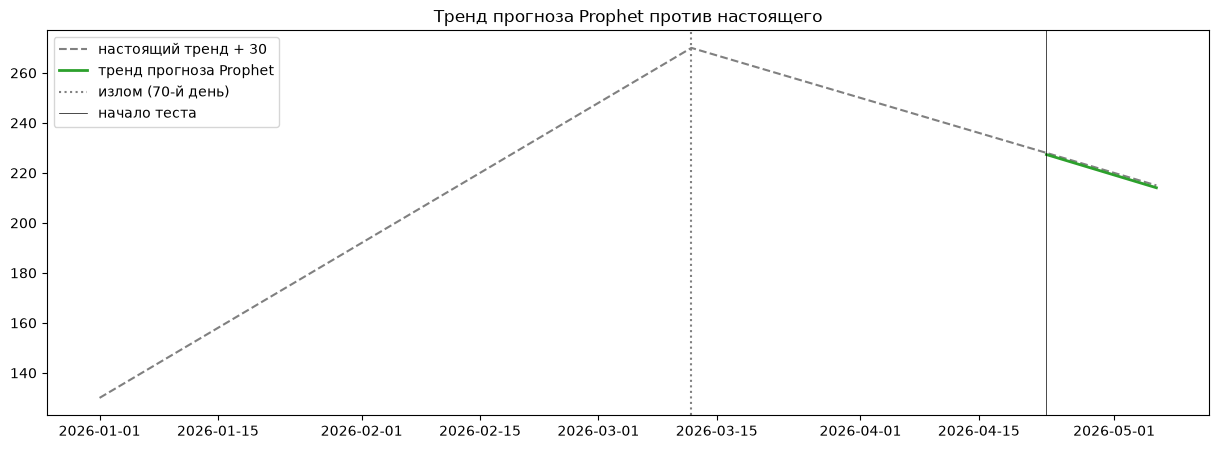

In [33]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(true_trend.index, true_trend.values, color="grey", linestyle="--", label="настоящий тренд + 30")
ax.plot(trend_fc.index, trend_fc.values, color="C2", linewidth=2, label="тренд прогноза Prophet")
ax.axvline(ts.timestamps[break_day], color="grey", linestyle=":", label="излом (70-й день)")
ax.axvline(test_ts.timestamps[0], color="black", linewidth=0.5, label="начало теста")
ax.legend(loc="upper left")
ax.set_title("Тренд прогноза Prophet против настоящего");

#### Выводы

- **Тренд в прогнозе — прямая** с наклоном −1.02 в день. Это продолжение последнего отрезка тренда после излома, а не усреднение роста и падения. Prophet правильно понял, что сейчас ряд падает на 1 заказ в день.
- **Наклон почти точный**: −1.02 против настоящего −1. Его оценка опирается на все 42 дня после излома, а не на последние несколько дней, как у `HoltWintersModel`. Поэтому шум усредняется.
- **Расхождение маленькое, но растёт**: от −0.67 до −0.94 заказа за 14 дней. Тренд Prophet стартует на 0.67 ниже настоящего (оценка уровня) и каждый день отстаёт ещё на 0.02 (лишняя «крутизна» наклона). На горизонте 14 дней это меньше 0.5% от уровня ряда, но на длинном горизонте даже маленькая ошибка в наклоне накапливается линейно.
- **Ограничение:** тренд Prophet за пределами истории — всегда прямая с последним наклоном (раздел 1.3). Если ряд и дальше будет падать на 1 в день, прогноз верный. Если падение замедлится или сменится ростом, модель об этом не узнает, пока излом не попадёт в историю — и, как показал шаг 1.4, в её первые 80%.

### Шаг 2.5. Нерекурсивность

Prophet не подставляет свои прогнозы вместо факта: прогноз на дату — это просто значение $g(t) + s(t)$ в этой точке (раздел 1.1). Проверим, что из этого следует.

1. Через `prophet` напрямую (`model_prophet.get_model()["synthetic"].predict(...)`) спрогнозируй **только одну дату** — 28-й день после конца train — и сравни с 28-й точкой прогноза `model_prophet` на 28 дней.
2. Сделай прогноз на 28 дней рекурсивной моделью `MovingAverageModel(window=7)` и нарисуй его рядом с Prophet.

- Совпадает ли прогноз на одну дату с 28-й точкой полного прогноза? Могла бы `MovingAverageModel` выдать прогноз на 28-й день, не посчитав дни 1…27?
- Что происходит с хвостом прогноза `MovingAverageModel` и почему? Что сохраняет Prophet на любом горизонте?

> Ловушка: сравнение «прогноз на 14 дней против первых 14 точек прогноза на 28» нерекурсивность **не** показывает — точки совпадут и у `MovingAverageModel`. Рекурсия детерминирована: прогнозы дней 1…13, на которые опирается 14-й, одинаковые при любом горизонте.

In [34]:
# Prophet считает прогноз на любую дату напрямую — как значение g(t) + s(t) в этой точке
prophet_raw = model_prophet.get_model()["synthetic"]  # объект prophet.Prophet

forecast_28 = model_prophet.forecast(train_ts.make_future(future_steps=28))[:, "synthetic", "target"]
day_28 = forecast_28.index[-1]

# Прогноз только на одну дату — 28-й день после конца train, без дней 1…27
single_day = prophet_raw.predict(pd.DataFrame({"ds": [day_28]}))["yhat"].iloc[0]

print(f"{day_28.date()}: напрямую {single_day:.4f} | 28-я точка полного прогноза {forecast_28.iloc[-1]:.4f}")

2026-05-20: напрямую 230.5288 | 28-я точка полного прогноза 230.5288


,prophet,moving_average
timestamp,,
2026-05-14,185.18,238.33
2026-05-15,195.49,238.36
2026-05-16,187.93,238.37
2026-05-17,198.50,238.37
2026-05-18,201.09,238.36
2026-05-19,221.10,238.35
2026-05-20,230.53,238.35


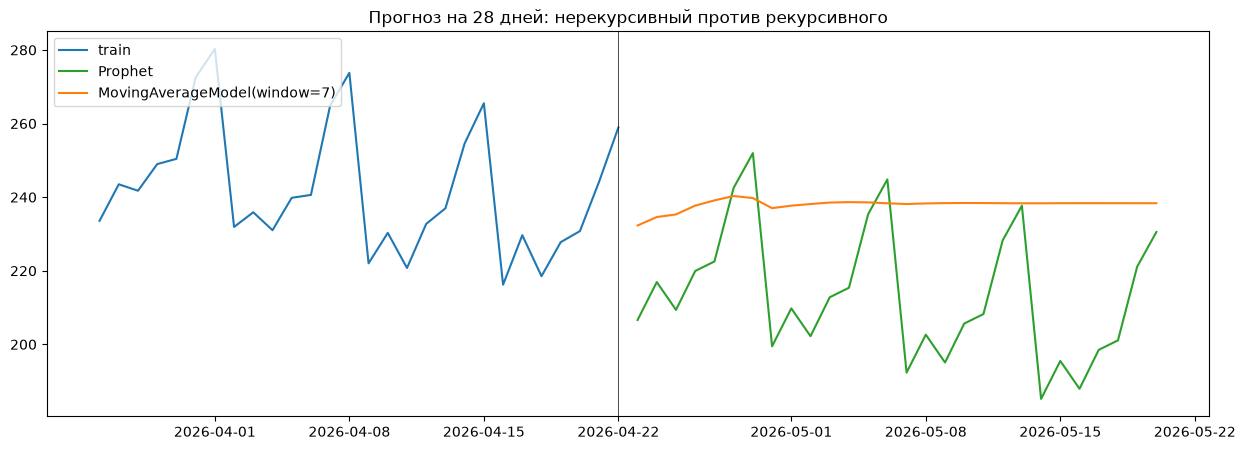

In [35]:
# Рекурсивная модель для сравнения: каждый следующий день — среднее 7 предыдущих, включая собственные прогнозы
from etna.models import MovingAverageModel

model_ma = MovingAverageModel(window=7)
model_ma.fit(train_ts)
# MovingAverageModel нужен контекст: последние context_size точек train (как в тетради про MovingAverageModel)
forecast_ma_28 = model_ma.forecast(
    train_ts.make_future(future_steps=28, tail_steps=model_ma.context_size),
    prediction_size=28,
)[:, "synthetic", "target"]

horizon_df = pd.DataFrame({
    "prophet": forecast_28,
    "moving_average": forecast_ma_28,
})

fig, ax = plt.subplots(figsize=(15, 5))
tail = train_ts[:, "synthetic", "target"].iloc[-28:]
ax.plot(tail.index, tail.values, color="C0", label="train")
ax.plot(horizon_df.index, horizon_df["prophet"], color="C2", label="Prophet")
ax.plot(horizon_df.index, horizon_df["moving_average"], color="C1", label="MovingAverageModel(window=7)")
ax.axvline(train_ts.timestamps[-1], color="black", linewidth=0.5)
ax.legend(loc="upper left")
ax.set_title("Прогноз на 28 дней: нерекурсивный против рекурсивного");

horizon_df.tail(7).round(2)

#### Выводы

- **Prophet прогнозирует любую дату напрямую.** Прогноз, сделанный только на 28-й день (дни 1…27 модели не передаём), совпадает с 28-й точкой полного прогноза на 28 дней: 230.5288 = 230.5288. Модели не нужны промежуточные дни — она просто подставляет дату в $g(t) + s(t)$. `MovingAverageModel` так не может: её прогноз на 28-й день — это среднее прогнозов 21…27-го дня, которые сами собраны из прогнозов, и так до конца train.
- **Рекурсия «съедает» структуру ряда.** Через неделю после конца train `MovingAverageModel` усредняет уже только собственные прогнозы, и прогноз вырождается в почти постоянную линию: недельная «пила» сглаживается, тренд пропадает. Каждый шаг — среднее предыдущих, поэтому любые колебания затухают.
- **Prophet держит структуру на любом горизонте:** прямая тренда с последним наклоном плюс та же недельная волна, что в первую неделю. Ошибка не накапливается от шага к шагу — но и не исправляется: если тренд выбран неверно, прогноз уходит от факта линейно (шаг 2.4).
- **Отсюда и отсутствие «золотого правила»** из тетрадей про `MovingAverageModel` / `SeasonalMovingAverageModel`: там горизонт ограничен тем, когда модель начинает опираться на свои прогнозы. У Prophet горизонт ограничен только тем, насколько долго можно верить продолжению тренда.

## Задание 3. Синтетика: перекрёстная проверка `expand` vs `constant`

Знакомимся с `Pipeline.backtest` (раздел 1.4) на синтетике из Задания 1: ряд `ts` с изломом на 70-м дне. Модель — `ProphetModel()` по умолчанию.

### Шаг 3.1. Первый backtest

Собери `Pipeline(model=ProphetModel(), transforms=[], horizon=HORIZON)` и запусти `backtest` на **всём** ряде `ts` (не на train!) с `metrics=[SMAPE()]`, `n_folds=4`, `mode="expand"`.

Помни: в ETNA 3.0.0 результат — словарь с ключами `metrics`, `forecasts`, `fold_info`, `pipelines` (раздел 1.4).

In [36]:
# Конвейер: модель + преобразования (пока пустой список) + горизонт
pipeline = Pipeline(model=ProphetModel(), transforms=[], horizon=HORIZON)

# backtest — на ВСЁМ ряде ts (train + test): фолды нарезаются внутри
result = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE()],
    n_folds=4,
    mode="expand",
    joblib_params=dict(verbose=0),  # без прогресс-лога joblib
)

# В ETNA 3.0.0 результат — словарь
for key, value in result.items():
    kind = f"список из {len(value)} × {type(value[0]).__name__}" if isinstance(value, list) else f"{type(value).__name__} {value.shape}"
    print(f"{key:<10} → {kind}")

metrics    → DataFrame (4, 3)
forecasts  → список из 4 × TSDataset
fold_info  → DataFrame (4, 5)
pipelines  → список из 4 × Pipeline


#### Выводы

- `backtest` запускается у **конвейера** `Pipeline`, а не у модели, и получает **весь** ряд `ts`: train и test для каждого фолда он нарезает сам. Модель внутри обучается заново на каждом фолде (`refit=True` по умолчанию).
- Результат в ETNA 3.0.0 — словарь из четырёх частей:
  - `metrics` — датафрейм: SMAPE по каждой паре (сегмент, фолд), у нас 4 строки;
  - `forecasts` — список из 4 `TSDataset`, прогноз каждого фолда отдельно;
  - `fold_info` — датафрейм с датами train / test каждого фолда;
  - `pipelines` — 4 обученных конвейера, по одному на фолд.
- В пособии (ETNA 2.x) тот же вызов возвращал кортеж `metrics_df, forecast_df, fold_info_df`, а прогнозы были одним широким датафреймом. Код из пособия в этом месте нужно переписывать на ключи словаря.

### Шаг 3.2. Как нарезаны фолды

Посмотри `result["fold_info"]`.

- Какие даты у train и test каждого фолда?
- На каком фолде тестовое окно совпадает с holdout из Задания 1 — и совпадает ли SMAPE на нём?

In [39]:
# Даты train/test каждого фолда + SMAPE фолда. Номера дней — от начала ряда (как break_day в make_break_series)
start_date = ts.timestamps[0]
to_day = lambda d: (d - start_date).days

folds_df = result["fold_info"].set_index("fold_number")
folds_df["train_days"] = (folds_df["train_end_time"] - folds_df["train_start_time"]).dt.days + 1
folds_df["test_start_day"] = folds_df["test_start_time"].map(to_day)
folds_df["test_end_day"] = folds_df["test_end_time"].map(to_day)
folds_df["smape"] = result["metrics"].set_index("fold_number")["SMAPE"]


# Holdout из Задания 1: тестовое окно и SMAPE Prophet
print(f"holdout Задания 1: test {test_ts.timestamps[0].date()} … {test_ts.timestamps[-1].date()}, SMAPE = {res['errors']['prophet']:.2f}")
print(f"последний фолд:    test {folds_df['test_start_time'].iloc[-1].date()} … {folds_df['test_end_time'].iloc[-1].date()}, SMAPE = {folds_df['smape'].iloc[-1]:.2f}")

folds_df

holdout Задания 1: test 2026-04-23 … 2026-05-06, SMAPE = 1.35
последний фолд:    test 2026-04-23 … 2026-05-06, SMAPE = 1.35


,train_start_time,train_end_time,test_start_time,test_end_time,train_days,test_start_day,test_end_day,smape
fold_number,,,,,,,,
0,2026-01-01,2026-03-11,2026-03-12,2026-03-25,70,70,83,7.355063
1,2026-01-01,2026-03-25,2026-03-26,2026-04-08,84,84,97,4.100224
2,2026-01-01,2026-04-08,2026-04-09,2026-04-22,98,98,111,0.904877
3,2026-01-01,2026-04-22,2026-04-23,2026-05-06,112,112,125,1.349056


#### Выводы
- **Режим `expand`:** начало train у всех фолдов одно и то же (2026-01-01), а конец сдвигается на 14 дней — train растёт 70 → 84 → 98 → 112 дней. Каждый следующий фолд видит всю историю предыдущего плюс ещё одно тестовое окно.
- **Тестовые окна идут встык и не пересекаются:** по 14 дней (`stride` = `horizon` по умолчанию), нарезаются с конца ряда назад. Вместе 4 фолда покрывают последние 56 дней ряда.
- **Последний фолд (3) — это ровно holdout из Задания 1:** тот же train (дни 0…111) и тот же test (2026-04-23 … 2026-05-06), и SMAPE тот же — 1.35. Обычный сплит `train_test_split` — это частный случай backtest с одним фолдом.
- Значит, holdout из Задания 1 — лишь одно из четырёх окон, причём самое «удобное»: к нему у модели больше всего истории. Как модель справлялась в остальных окнах — в шаге 3.3.

### Шаг 3.3. Ошибка по фолдам

Посмотри `result["metrics"]` и визуализируй `plot_backtest(result["forecasts"], ts)` — и ещё раз с `history_len="all"`.

- На каком фолде ошибка самая большая?
- Сопоставь даты этого фолда с 70-м днём: что модель «знала» об изломе в момент прогноза?

In [40]:
# SMAPE по фолдам + что модель каждого фолда знала о тренде к концу своего train
break_day = 70  # излом в ts — как в make_break_series() по умолчанию
fold_rows = []
for fold_number, fold_pipeline in enumerate(result["pipelines"]):
    prophet_fold = fold_pipeline.model.get_model()["synthetic"]  # prophet.Prophet, обученный на train этого фолда
    trend_fold = prophet_fold.predict(prophet_fold.history[["ds"]])["trend"]
    fold_rows.append({
        "fold_number": fold_number,
        "train_end_day": to_day(prophet_fold.history["ds"].max()),
        "last_changepoint_day": to_day(prophet_fold.changepoints.iloc[-1]),  # последний кандидат в изломы (80% train)
        "end_slope": trend_fold.diff().iloc[-1],                               # наклон, с которым модель уходит в тест
        "smape": folds_df.loc[fold_number, "smape"],
    })

print(f"излом — на {break_day}-м дне")
pd.DataFrame(fold_rows).set_index("fold_number").round(2)

излом — на 70-м дне


,train_end_day,last_changepoint_day,end_slope,smape
fold_number,,,,
0,69,55,2.03,7.36
1,83,66,-0.21,4.10
2,97,77,-1.04,0.90
3,111,88,-1.02,1.35


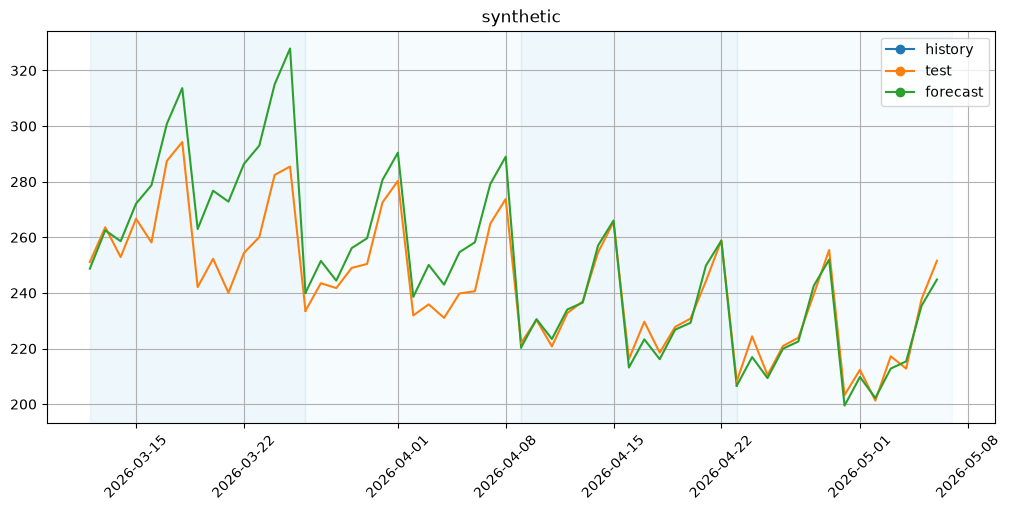

In [42]:
plot_backtest(result["forecasts"], ts)

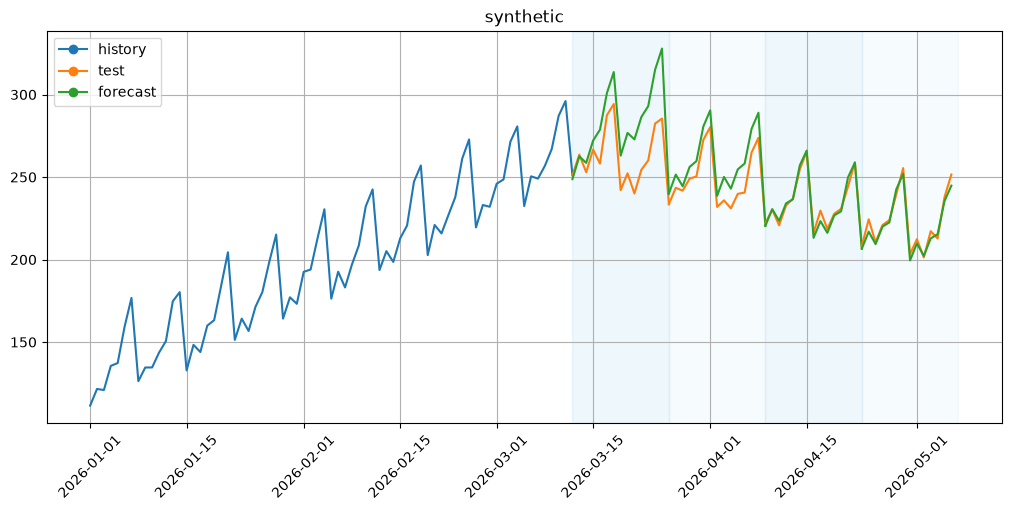

In [43]:
plot_backtest(result["forecasts"], ts, history_len="all")

#### Выводы

| fold | train (дни) | последний кандидат | наклон в конце train | SMAPE |
|---|---|---|---|---|
| 0 | 0…69 | 55 | +2.03 | **7.36** |
| 1 | 0…83 | 66 | −0.21 | 4.10 |
| 2 | 0…97 | 77 | −1.04 | 0.90 |
| 3 | 0…111 | 88 | −1.02 | 1.35 |

- **Хуже всего фолд 0 (7.36): излом для него в будущем.** Train заканчивается на 69-м дне, тест начинается ровно в день излома. Модель видела только рост +2 и честно продолжила его, а ряд пошёл вниз. На графике с `history_len="all"` видно, как зелёный прогноз в первом окне уходит вверх от оранжевого факта. Это шаг 1.4 с изломом на 115-м дне, только в backtest: смену тренда в будущем не поймает никто.
- **Фолд 1 (4.10): излом уже в train, но в слепой зоне.** После излома 14 дней, но кандидаты в изломы стоят только до 66-го дня (80% от 84), а излом на 70-м. Ближайший кандидат на 66-м дне «ломает» тренд на 4 дня раньше, и наклон после него — компромисс между ростом и падением: −0.21 вместо −1. Модель уже знает, что рост кончился, но ещё не знает, насколько быстро ряд падает.
- **Фолды 2–3 (0.90 и 1.35): излом внутри зоны поиска,** наклон −1.04 / −1.02 — почти настоящий −1. Модель хорошо прогнозирует.
- **Главное:** holdout из Задания 1 (фолд 3, SMAPE 1.35) показывал только лучший случай. Средний SMAPE по 4 фолдам ≈ 3.4, в 2.5 раза хуже. Одно тестовое окно сильно льстит модели, если ряд недавно менял поведение. Backtest показывает, как модель ведёт себя в момент смены режима и сразу после него.
- `plot_backtest` по умолчанию рисует только тестовые окна. С `history_len="all"` видна вся история перед ними, и сразу понятно, где излом относительно фолдов.

### Шаг 3.4. `constant` вместо `expand`

Повтори backtest с `mode="constant"` и сравни `fold_info` и метрики с шагами 3.2–3.3.

- Чем отличается train у фолдов?
- На каком фолде разница в SMAPE заметнее и почему?

In [46]:
# Тот же конвейер, но train скользит окном постоянной длины
result_constant = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE()],
    n_folds=4,
    mode="constant",
    joblib_params=dict(verbose=0),
)

# expand vs constant по фолдам: где начинается train, сколько в нём дней, что модель знала о тренде, SMAPE
compare_rows = []
for fold_number in range(4):
    for mode, res_mode in [("expand", result), ("constant", result_constant)]:
        prophet_fold = res_mode["pipelines"][fold_number].model.get_model()["synthetic"]
        history = prophet_fold.history["ds"]
        trend_fold = prophet_fold.predict(prophet_fold.history[["ds"]])["trend"]
        compare_rows.append({
            "fold_number": fold_number,
            "mode": mode,
            "train_start_day": to_day(history.min()),
            "train_end_day": to_day(history.max()),
            "train_days": len(history),
            "last_changepoint_day": to_day(prophet_fold.changepoints.iloc[-1]),
            "end_slope": trend_fold.diff().iloc[-1],
            "smape": res_mode["metrics"].set_index("fold_number").loc[fold_number, "SMAPE"],
        })

compare_modes_df = pd.DataFrame(compare_rows).set_index(["fold_number", "mode"])
compare_modes_df.round(2)

train_start_day  train_end_day  train_days  \
fold_number mode                                                   
0           expand                  0             69          70   
            constant                0             69          70   
1           expand                  0             83          84   
            constant               14             83          70   
2           expand                  0             97          98   
            constant               28             97          70   
3           expand                  0            111         112   
            constant               42            111          70   

                      last_changepoint_day  end_slope  smape  
fold_number mode                                              
0           expand                      55       2.03   7.36  
            constant                    55       2.03   7.36  
1           expand                      66      -0.21   4.10  
            constant                    69      -0.80   1.35  
2           expand                      77      -1.04   0.90  
            constant                    83      -1.03   0.99  
3           expand                      88      -1.02   1.35  
            constant                    97      -1.02   1.40

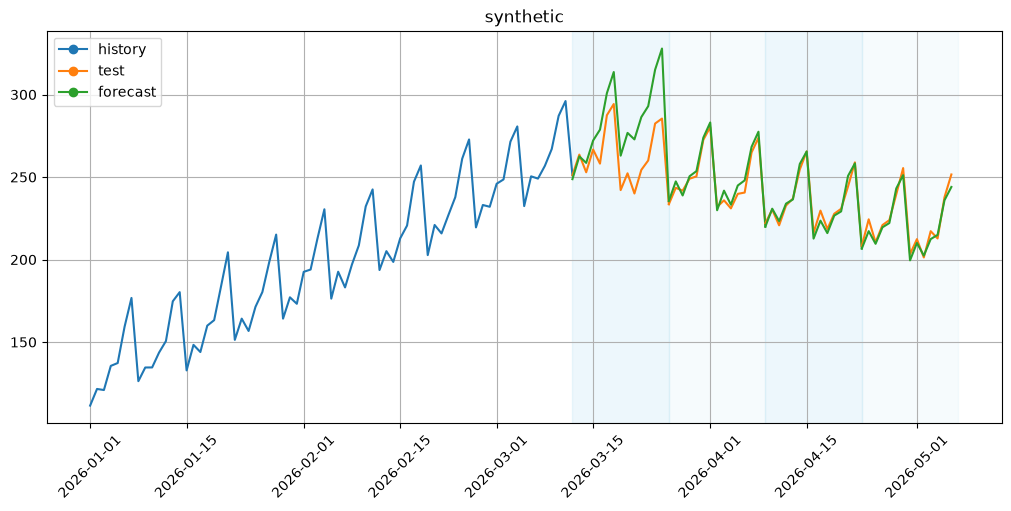

In [47]:
plot_backtest(result_constant["forecasts"], ts, history_len="all")

#### Выводы

| fold | mode | train (дни) | последний кандидат | наклон в конце | SMAPE |
|---|---|---|---|---|---|
| 0 | expand / constant | 0…69 | 55 | +2.03 | 7.36 / 7.36 |
| 1 | expand | 0…83 | 66 | −0.21 | **4.10** |
| 1 | constant | 14…83 | 69 | −0.80 | **1.35** |
| 2 | expand / constant | 0…97 / 28…97 | 77 / 83 | −1.04 / −1.03 | 0.90 / 0.99 |
| 3 | expand / constant | 0…111 / 42…111 | 88 / 97 | −1.02 / −1.02 | 1.35 / 1.40 |

- **Чем отличается train:** в `constant` у всех фолдов одна длина — 70 дней, как у первого фолда, и окно скользит вперёд на 14 дней (начало 0 → 14 → 28 → 42). В `expand` начало всегда 0, а train растёт. Фолд 0 в обоих режимах одинаковый — отсюда одинаковый SMAPE.
- **Где разница заметнее — фолд 1, и в пользу `constant` (1.35 против 4.10).** На первый взгляд странно: меньше истории, а прогноз лучше. Причина — слепая зона Prophet. 80% для кандидатов в изломы считаются **от начала train**. В `expand` train 0…83, кандидаты до 66-го дня, и излом на 70-м в зону не попадает. В `constant` train 14…83, кандидаты сдвигаются вместе с окном до 69-го дня, излом почти пойман, наклон −0.80 вместо −0.21.
- **На фолдах 2–3 `constant` чуть хуже (0.99 против 0.90, 1.40 против 1.35):** излом и так в зоне поиска в обоих режимах, а у `constant` просто меньше данных для оценки недельной волны и наклона. Разница в пределах шума.
- **В среднем `constant` лучше (2.77 против 3.43),** но весь выигрыш даёт один фолд 1 — и даёт его не потому, что «старые данные вредят», а из-за того, как сдвинулась слепая зона. Делать отсюда вывод «`constant` лучше» нельзя: это свойство конкретного ряда и положения излома.
- **Практический смысл режимов:** `expand` повторяет прод, где модель переобучают на всей накопленной истории. `constant` полезен, когда старая история устарела, или чтобы сравнивать фолды при равной длине train. Для Prophet есть ещё одна тонкость: длина train меняет, где проходит граница 80% `changepoint_range`.

### Шаг 3.5. Агрегированные метрики

Повтори `expand` с `aggregate_metrics=True`.

- Что теперь в `result["metrics"]`? Как это число связано с метриками по фолдам из шага 3.3?

In [50]:
# Тот же expand-backtest, но метрики агрегируются по фолдам
result_agg = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE()],
    n_folds=4,
    mode="expand",
    aggregate_metrics=True,
    joblib_params=dict(verbose=0),
)

# Сверяем с метриками по фолдам из шага 3.1
smape_by_fold = result["metrics"]["SMAPE"]
print(f"aggregate_metrics=True:      {result_agg['metrics']['SMAPE'].iloc[0]:.4f}")
print(f"среднее SMAPE по 4 фолдам:   {smape_by_fold.mean():.4f}")
print(f"разброс по фолдам: от {smape_by_fold.min():.2f} до {smape_by_fold.max():.2f}, std = {smape_by_fold.std():.2f}")


# result_agg["metrics"]

aggregate_metrics=True:      3.4273
среднее SMAPE по 4 фолдам:   3.4273
разброс по фолдам: от 0.90 до 7.36, std = 2.98


#### Выводы

- С `aggregate_metrics=True` в `result["metrics"]` вместо строки на каждую пару (сегмент, фолд) остаётся **одна строка на сегмент**, а колонка `fold_number` пропадает.
- Значение — **простое среднее SMAPE по фолдам**: 3.4273, ровно столько же даёт `result["metrics"]["SMAPE"].mean()` из шага 3.1. Это удобная одна цифра для сравнения моделей и конфигураций — её и будем логировать в MLflow в бонусе как `smape_backtest_macro`.
- **Но среднее прячет разброс:** по фолдам SMAPE от 0.90 до 7.36, стандартное отклонение 2.98 — почти как само среднее. За одной цифрой 3.43 стоят и окна, где модель почти идеальна, и окно, где она промахнулась из-за излома в будущем.
- Отсюда правило: для сравнения моделей смотреть агрегат, а прежде чем делать выводы — заглянуть в метрики по фолдам (`aggregate_metrics=False`). Если разница между моделями меньше разброса между фолдами, она может быть случайной. Это проверим на реальных юнитах в шаге 5.4.

## Задание 4. Загрузи данные по 2 юнитам размера `10+`

Переходим к реальным данным — те же 2 юнита и тот же период, что для предыдущих моделей.

### Шаг 4.1. Загрузка и сплит

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) с 2026-04-01 — так же, как для предыдущих моделей.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Раздели на train/test (последние `HORIZON` = 14 дней).

#### Выводы

### Шаг 4.2. Гипотеза до обучения

По графикам из тетради про `HoltWintersModel` ты уже знаешь, что тренда у этих рядов почти нет, а недельная «пила» сильная.

- Какие параметры Prophet из раздела 1.2 это подсказывает попробовать?

#### Выводы

## Задание 5. Prophet на двух юнитах: holdout и backtest

Подбираем конфигурацию Prophet на данных из Задания 4 и проверяем, насколько можно доверять выводу по одному тестовому окну.

### Шаг 5.1. Несколько конфигураций

Обучи на обоих сегментах:
- `ProphetModel()` — по умолчанию;
- `ProphetModel(growth="flat")` — без тренда;
- `ProphetModel(seasonality_mode="multiplicative")`;
- `ProphetModel(changepoint_prior_scale=0.5)` и `ProphetModel(changepoint_prior_scale=0.005)` — гибкий и жёсткий тренд.

#### Выводы

### Шаг 5.2. Таблица SMAPE

Посчитай `SMAPE` per-segment и `mode="macro"`, собери в одну таблицу: строки — конфигурации, колонки — юниты + macro.

Для ориентира: на тех же 2 юнитах и 14 днях `HoltWintersModel(trend=None, seasonal="add")` давал macro 7.77, лучший `SARIMAXModel` — 7.42.

- Какая конфигурация лучшая? Подтвердилась ли гипотеза из Задания 4?
- Как повёл себя гибкий тренд (`changepoint_prior_scale=0.5`) на шумных данных — в отличие от синтетики?

#### Выводы

### Шаг 5.3. Лучшая конфигурация: прогноз и компоненты

Для лучшей конфигурации — `plot_forecast` и разложение на компоненты (`return_components=True`).

- Как выглядит тренд в прогнозе: горизонтальный, растёт, падает?

#### Выводы

### Шаг 5.4. Holdout — это одно окно

Прогони через `backtest` (`n_folds=5`, `mode="expand"`) три конвейера: лучший Prophet, Prophet по умолчанию и `HoltWintersModel(trend=None, seasonal="add", seasonal_periods=7)`.

- С `aggregate_metrics=True`: сохраняется ли порядок моделей, который был на holdout?
- С `aggregate_metrics=False`: насколько разброс SMAPE между фолдами больше разницы между моделями?
- Можно ли по одному тестовому окну в 14 дней уверенно выбирать между моделями с разницей в 0.5–1 SMAPE?

#### Выводы

## Задание 6. Длинная история: годовая сезонность

У юнитов `10+` факты есть с 2022 года. Проверим, что даст Prophet длинная история: при train ≥ 2 лет он сам включает годовую сезонность (раздел 1.2).

### Шаг 6.1. Датасет с 2024 года

Собери второй `TSDataset` по тем же 2 юнитам, но **с 2024-01-01**. Сплит тот же: последние 14 дней — test, то есть тестовое окно совпадает с Заданием 5.

#### Выводы

### Шаг 6.2. Смотрим на длинную историю

Построй `plot()` на длинной истории.

- Видна ли годовая волна?
- Меняется ли уровень от года к году — и как при этом ведёт себя ширина недельной «пилы»?

#### Выводы

### Шаг 6.3. Аддитивный и мультипликативный Prophet

Обучи `ProphetModel()` (аддитивная сезонность) и `ProphetModel(seasonality_mode="multiplicative")`.

Убедись, что годовая сезонность включилась: `model.get_model()[segment].seasonalities`.

#### Выводы

### Шаг 6.4. Короткая история против длинной

Сравни SMAPE с короткой историей из Задания 5 — таблица 2 × 2 (история × режим сезонности).

- Где длинная история помогла, а где навредила?
- Объясни результат по таксономии add/mul из тетради про `HoltWintersModel`: что случается с аддитивной недельной волной постоянного размаха, когда уровень ряда за 2.5 года сильно менялся?

#### Выводы

### Шаг 6.5. Годовая компонента

Посмотри на годовую компоненту:
- для аддитивной модели — через `return_components=True`;
- для мультипликативной (раздел 1.3: в ETNA разложение не работает) — через `prophet` напрямую: `m = model.get_model()[segment]`, `m.plot_components(m.predict(m.make_future_dataframe(HORIZON)))`.

- Где на годовой кривой сейчас конец августа — на подъёме или на спаде?

#### Выводы

## Бонус. Общая картина по всем 10 юнитам + логирование

Прогоняем лучшие конфигурации на всех 10 юнитах и логируем в MLflow — по аналогии с бонусом `HoltWintersModel`, чтобы Prophet встал в одну таблицу с прошлыми моделями.

### Шаг Б.1. Все 10 юнитов: holdout и метрики

Прогони 2–3 лучшие конфигурации из Заданий 5–6 сразу на всех 10 юнитах на стандартном периоде (с 2026-04-01, без фильтра по `unit_size`).

Посчитай весь набор метрик на holdout — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно (`smape_macro`, `mape_macro`, `mae_macro`, `wape_pooled`, `bias_pooled`, `fit_sec`) — те же имена, что у прошлых запусков.

#### Выводы

### Шаг Б.2. Метрика по backtest

Для каждой конфигурации прогони `backtest` (`n_folds=5`, `mode="expand"`, `aggregate_metrics=True`) и добавь к агрегатам `smape_backtest_macro` — среднее SMAPE по юнитам и 5 фолдам. Это более устойчивая оценка, чем 14 дней holdout.

Для сравнения прогони так же лучшую `HoltWintersModel` — её залогируем отдельным запуском, чтобы у прошлой модели тоже была эта метрика.

#### Выводы

### Шаг Б.3. Таблица по юнитам

Собери таблицу `result` по юнитам: `segment` / `unit_size` / `pick_reason` / `total_orders` + все метрики + SMAPE по backtest.

- На каких юнитах Prophet выигрывает у `HoltWintersModel`, а на каких проигрывает?

#### Выводы

### Шаг Б.4. Логирование в MLflow

Залогируй каждую конфигурацию отдельным запуском через `log_to_mlflow(...)`:
- имя запуска: `Prophet_<вариант>_ch07_all_10_day`, например `Prophet_default_ch07_all_10_day`, `Prophet_mult_ch07_all_10_day`;
- теги: `{"chapter": "ch07", "units_scope": "all_10", "granularity": "day", "model_family": "prophet", "approach": "one_config", "impl": "prophet"}` + теги варианта (`"growth"`, `"seasonality_mode"`, `"changepoint_prior_scale"`);
- параметры: параметры модели + `horizon`, а для backtest-метрики — `backtest_n_folds` и `backtest_mode`.

#### Выводы

### Шаг Б.5. Сравнение с прошлыми моделями

Сравни в MLflow (или через `mlflow.search_runs`, как в конце тетради про `HoltWintersModel`) лучшие Prophet с `HoltWinters_*` и `SARIMAX_*` по юнитам.

#### Выводы

### Шаг Б.6. *(По желанию)* Длинная история на всех 10 юнитах

Осторожно: у части юнитов до открытия в данных стоят нули (`8a399130` и `a5cd0472` открылись только в марте 2026). Обрежь каждый ряд по первому ненулевому факту, а при логировании добавь тег `"history": "full"` — тестовое окно то же, поэтому метрики сравнимы, но train разной длины.

#### Выводы